<a href="https://colab.research.google.com/github/jacielefreitas63-tech/analisr-dados-ecommerce/blob/main/notebooks/analise_ecommerce.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Por favor, selecione o arquivo 'ecommerce_estatistica.csv' do seu computador:


Saving ecommerce_estatistica.csv to ecommerce_estatistica (1).csv

Colunas identificadas no seu arquivo: ['unnamed: 0', 'título', 'nota_produto', 'n_avaliações', 'desconto', 'marca', 'material', 'gênero', 'temporada', 'review1', 'review2', 'review3', 'qtd_vendidos', 'preco', 'nota_minmax', 'n_avaliações_minmax', 'desconto_minmax', 'preço_minmax', 'marca_cod', 'material_cod', 'temporada_cod', 'qtd_vendidos_cod', 'marca_freq', 'material_freq']
Gerando os gráficos...



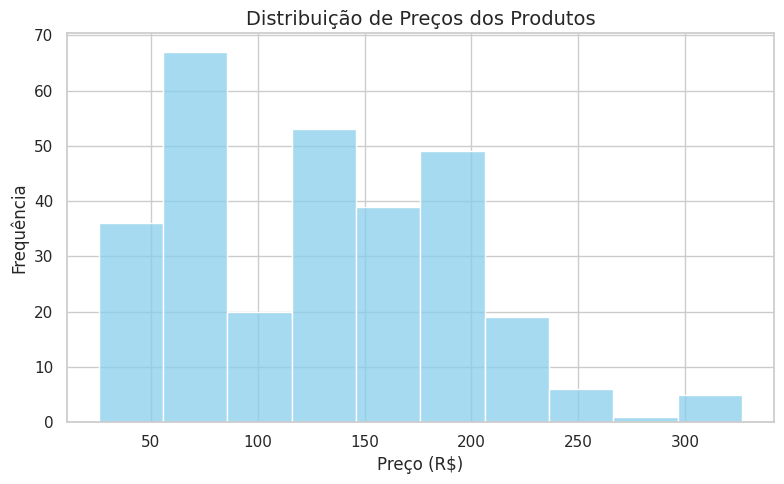

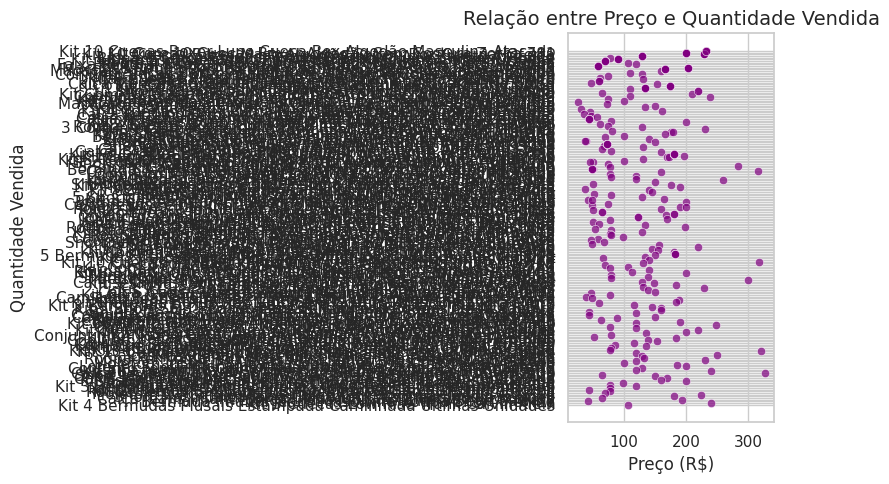

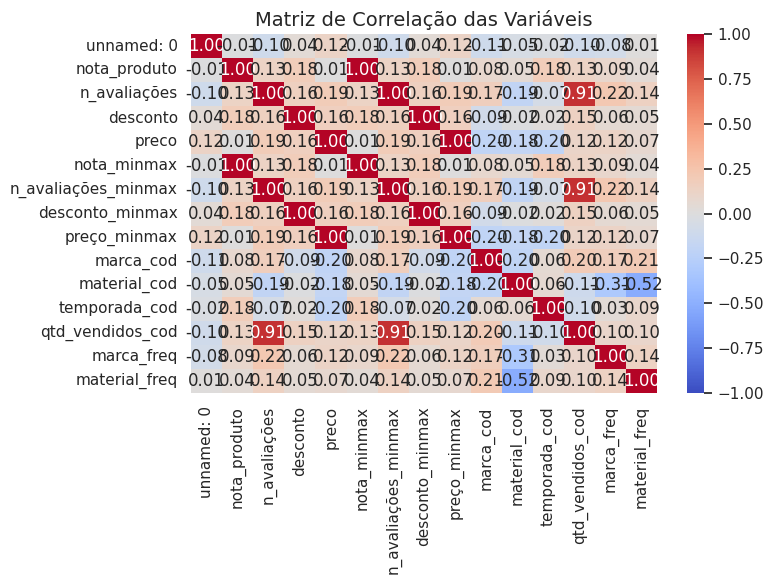

/tmp/ipykernel_399/4054352319.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x=col_cat, y=col_fat, estimator=sum, errorbar=None, palette="viridis")


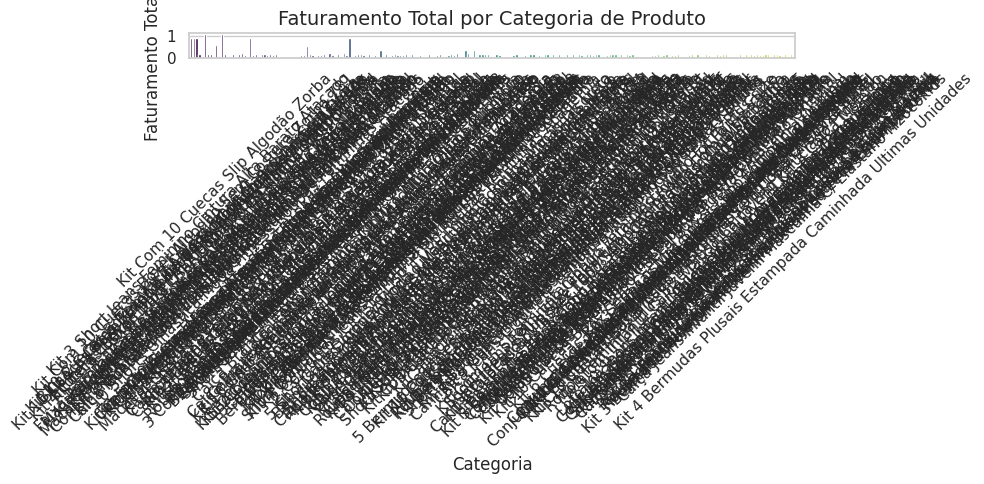

/tmp/ipykernel_399/4054352319.py:85: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


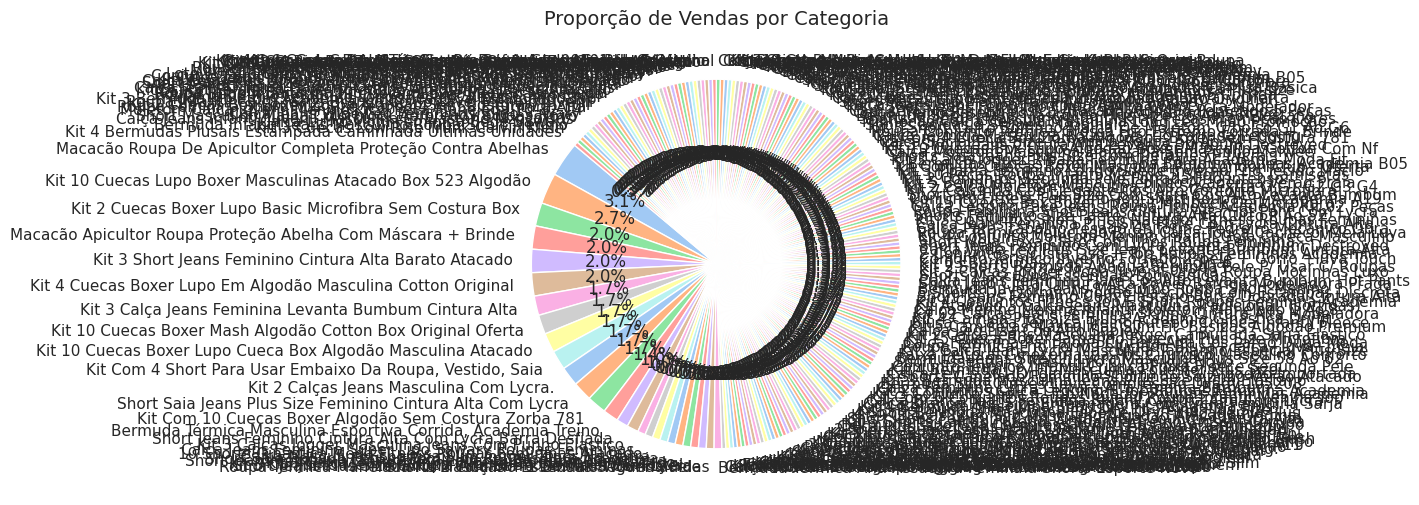

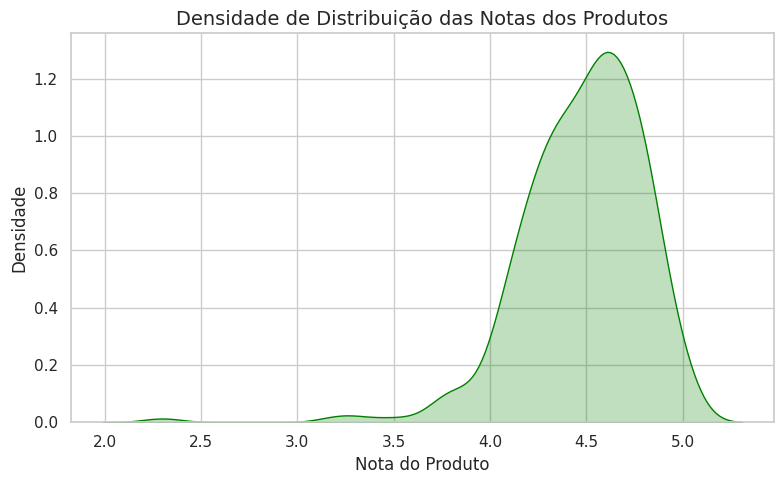

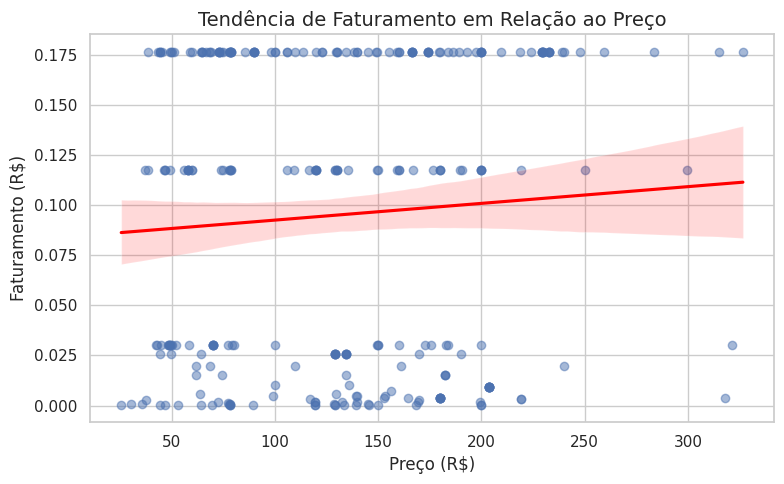

In [3]:
# 1. Importação das bibliotecas necessárias
import io
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from google.colab import files

# Configuração visual dos gráficos
sns.set_theme(style="whitegrid")

# 2. Upload do arquivo CSV
print("Por favor, selecione o arquivo 'ecommerce_estatistica.csv' do seu computador:")
uploaded = files.upload()

# 3. Lendo o arquivo e padronizando as colunas
nome_arquivo = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[nome_arquivo]))

# AJUSTE AUTOMÁTICO: Remove espaços e deixa tudo em letras minúsculas
df.columns = df.columns.str.strip().str.lower()

# Dicionário para garantir o mapeamento correto caso haja acentos no CSV
mapeamento = {
    "preço": "preco",
    "quantidade vendida": "qtd_vendida",
    "quantidade_vendida": "qtd_vendida",
    "nota": "nota_produto",
    "nota do produto": "nota_produto"
}
df = df.rename(columns=mapeamento)

print("\nColunas identificadas no seu arquivo:", list(df.columns))
print("Gerando os gráficos...\n")

# ==========================================
# CÓDIGO DOS GRÁFICOS (Seaborn / Matplotlib)
# ==========================================

# --- 1. Gráfico de Histograma ---
plt.figure(figsize=(8, 5))
col_preco = "preco" if "preco" in df.columns else df.columns[0]
sns.histplot(data=df, x=col_preco, kde=False, color="skyblue")
plt.title("Distribuição de Preços dos Produtos", fontsize=14)
plt.xlabel("Preço (R$)", fontsize=12)
plt.ylabel("Frequência", fontsize=12)
plt.tight_layout()
plt.show()

# --- 2. Gráfico de Dispersão ---
plt.figure(figsize=(8, 5))
col_qtd = "qtd_vendida" if "qtd_vendida" in df.columns else df.columns[1]
sns.scatterplot(data=df, x=col_preco, y=col_qtd, alpha=0.7, color="purple")
plt.title("Relação entre Preço e Quantidade Vendida", fontsize=14)
plt.xlabel("Preço (R$)", fontsize=12)
plt.ylabel("Quantidade Vendida", fontsize=12)
plt.tight_layout()
plt.show()

# --- 3. Mapa de Calor (Heatmap) ---
plt.figure(figsize=(8, 6))
colunas_numericas = df.select_dtypes(include=["float64", "int64"])
matriz_correlacao = colunas_numericas.corr()
sns.heatmap(matriz_correlacao, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Matriz de Correlação das Variáveis", fontsize=14)
plt.tight_layout()
plt.show()

# --- 4. Gráfico de Barra ---
plt.figure(figsize=(10, 5))
col_cat = "categoria" if "categoria" in df.columns else df.select_dtypes(include=["object"]).columns[0]
col_fat = "faturamento" if "faturamento" in df.columns else df.select_dtypes(include=["float64", "int64"]).columns[-1]
sns.barplot(data=df, x=col_cat, y=col_fat, estimator=sum, errorbar=None, palette="viridis")
plt.title("Faturamento Total por Categoria de Produto", fontsize=14)
plt.xlabel("Categoria", fontsize=12)
plt.ylabel("Faturamento Total (R$)", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# --- 5. Gráfico de Pizza ---
plt.figure(figsize=(6, 6))
dados_pizza = df[col_cat].value_counts()
plt.pie(dados_pizza, labels=dados_pizza.index, autopct="%1.1f%%", startangle=140, colors=sns.color_palette("pastel"))
plt.title("Proporção de Vendas por Categoria", fontsize=14)
plt.tight_layout()
plt.show()

# --- 6. Gráfico de Densidade ---
plt.figure(figsize=(8, 5))
col_nota = "nota_produto" if "nota_produto" in df.columns else df.select_dtypes(include=["float64", "int64"]).columns[2]
sns.kdeplot(data=df, x=col_nota, fill=True, color="green")
plt.title("Densidade de Distribuição das Notas dos Produtos", fontsize=14)
plt.xlabel("Nota do Produto", fontsize=12)
plt.ylabel("Densidade", fontsize=12)
plt.tight_layout()
plt.show()

# --- 7. Gráfico de Regressão ---
plt.figure(figsize=(8, 5))
sns.regplot(data=df, x=col_preco, y=col_fat, scatter_kws={"alpha":0.5}, line_kws={"color":"red"})
plt.title("Tendência de Faturamento em Relação ao Preço", fontsize=14)
plt.xlabel("Preço (R$)", fontsize=12)
plt.ylabel("Faturamento (R$)", fontsize=12)
plt.tight_layout()
plt.show()